<a href="https://colab.research.google.com/github/Ann-tech2025/Robotics-Final-Year-Project/blob/main/SER_speech_recognition_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
uwrfkaggler_ravdess_emotional_speech_audio_path = kagglehub.dataset_download('uwrfkaggler/ravdess-emotional-speech-audio')
ejlok1_toronto_emotional_speech_set_tess_path = kagglehub.dataset_download('ejlok1/toronto-emotional-speech-set-tess')
ejlok1_cremad_path = kagglehub.dataset_download('ejlok1/cremad')
ejlok1_surrey_audiovisual_expressed_emotion_savee_path = kagglehub.dataset_download('ejlok1/surrey-audiovisual-expressed-emotion-savee')

print('Data source import complete.')


In [ ]:
import os
import librosa
import numpy as np
import seaborn as sns
import librosa.display
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Reshape, Bidirectional, LSTM,
    Dense, Dropout
)
import numpy as np
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.utils import to_categorical


In [ ]:

SAMPLE_RATE = 22050
MFCC_COUNT = 40
MAX_LEN = 174

# ============================
# MFCC FUNCTION
# ============================
def extract_mfcc(file_path):
    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=MFCC_COUNT
    )
    mfcc = librosa.util.fix_length(mfcc, size=MAX_LEN, axis=1)
    return mfcc


X = []
y = []

#Ravdess Dataframe
Ravdess = "/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/"
ravdess_directory_list = os.listdir(Ravdess)

file_emotion = []
file_path = []
for dir in ravdess_directory_list:
    # as their are 20 different actors in our previous directory we need to extract files for each actor.
    actor = os.listdir(Ravdess + dir)
    for file in actor:
        part = file.split('.')[0]
        part = part.split('-')
        # third part in each file represents the emotion associated to that file.
        file_emotion.append(int(part[2]))
        file_path.append(Ravdess + dir + '/' + file)

# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Ravdess_df = pd.concat([emotion_df, path_df], axis=1)

# changing integers to actual emotions.
Ravdess_df.Emotions.replace({1:'neutral', 2:'calm', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 8:'surprise'}, inplace=True)
Ravdess_df.head()

# ==================================================
# TESS
# ==================================================
tess_path = "/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data"

tess_emotion_map = {
    "angry": 0,
    "happy": 1,
    "sad": 2,
    "neutral": 3,
    "fear": 4
}

for emotion_folder in os.listdir(tess_path):
    emotion_folder_path = os.path.join(tess_path, emotion_folder)

    if os.path.isdir(emotion_folder_path):

        emotion_label = emotion_folder.split("_")[-1].lower()

        if emotion_label in tess_emotion_map:
            for file in os.listdir(emotion_folder_path):
                if file.endswith(".wav"):
                    mfcc = extract_mfcc(os.path.join(emotion_folder_path, file))
                    X.append(mfcc)
                    y.append(tess_emotion_map[emotion_label])


# ==================================================
# CREMA-D
# ==================================================
crema_path = "/kaggle/input/cremad/AudioWAV"

crema_map = {
    "ANG": 0,
    "HAP": 1,
    "SAD": 2,
    "NEU": 3,
    "FEA": 4
}

for file in os.listdir(crema_path):
    if file.endswith(".wav"):
        parts = file.split("_")
        emotion_code = parts[2]

        if emotion_code in crema_map:
            mfcc = extract_mfcc(os.path.join(crema_path, file))
            X.append(mfcc)
            y.append(crema_map[emotion_code])


# ==================================================
# SAVEE
# ==================================================
savee_path = "/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL"

savee_map = {
    "_a": 0,    # angry
    "_h": 1,    # happy
    "_sa": 2,   # sad
    "_n": 3,    # neutral
    "_f": 4     # fear
}

for file in os.listdir(savee_path):
    fname = file.lower()

    for key in savee_map:
        if key in fname:
            mfcc = extract_mfcc(os.path.join(savee_path, file))
            X.append(mfcc)
            y.append(savee_map[key])
            break


# ==================================================
# FINAL
# ==================================================
X = np.array(X)
y = np.array(y)

# add channel dimension for CNN
X = X[..., np.newaxis]

print("Total samples:", X.shape)
print("Labels shape:", y.shape)


/tmp/ipykernel_117/2443836493.py:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Ravdess_df.Emotions.replace({1:'neutral', 2:'calm', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 8:'surprise'}, inplace=True)


Total samples: (8531, 40, 174, 1)
Labels shape: (8531,)


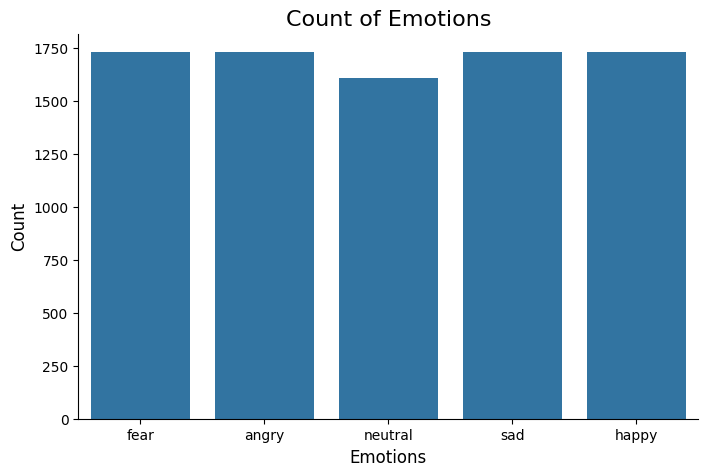

In [ ]:

# Create a simple DataFrame with your labels
df = pd.DataFrame({'Emotions': y})  # y contains integer labels

# Map integers to emotion names (same as before)
emotion_names = {0:'angry', 1:'happy', 2:'sad', 3:'neutral', 4:'fear'}
df['Emotions'] = df['Emotions'].map(emotion_names)

# Plot
plt.figure(figsize=(8,5))
sns.countplot(x='Emotions', data=df)
plt.title('Count of Emotions', size=16)
plt.ylabel('Count', size=12)
plt.xlabel('Emotions', size=12)
sns.despine(top=True, right=True)
plt.show()


In [ ]:
def create_waveplot(data, sr, e):
    plt.figure(figsize=(10, 3))
    plt.title('Waveplot for audio with {} emotion'.format(e), size=15)
    librosa.display.waveplot(data, sr=sr)
    plt.show()

def create_spectrogram(data, sr, e):
    # stft function converts the data into short term fourier transform
    X = librosa.stft(data)
    Xdb = librosa.amplitude_to_db(abs(X))
    plt.figure(figsize=(12, 3))
    plt.title('Spectrogram for audio with {} emotion'.format(e), size=15)
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
    #librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar()

In [ ]:
import numpy as np

X = (X - np.mean(X)) / np.std(X)
print("Features normalized. Shape:", X.shape)
from tensorflow.keras.utils import to_categorical

y_cat = to_categorical(y)
print("Labels one-hot encoded. Shape:", y_cat.shape)



Features normalized. Shape: (8531, 40, 174, 1)
Labels one-hot encoded. Shape: (8531, 5)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat,
    test_size=0.2,        # 20% of samples used for testing
    random_state=42,
    stratify=y            # keeps emotion distribution proportional
)

print("Training set:", X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)



Training set: (6824, 40, 174, 1) (6824, 5)
Testing set: (1707, 40, 174, 1) (1707, 5)


In [ ]:
X_train_cnn = X_train[..., np.newaxis]  # shape: (samples, 40, 174, 1)
X_test_cnn = X_test[..., np.newaxis]
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

num_classes = y_train.shape[1]  # 5 emotions

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(40, 174, 1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


In [ ]:
history = model.fit(
    X_train_cnn, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,  # 10% of training used as validation
    verbose=1
)


In [ ]:
test_loss, test_acc = model.evaluate(X_test_cnn, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

epochs = range(1, len(history.history['accuracy'])+1)

plt.figure(figsize=(18,6))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, history.history['loss'], label='Training Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


In [ ]:

# Convert predictions & true labels from one-hot
y_pred = np.argmax(model.predict(X_test_cnn), axis=1)
y_true = np.argmax(y_test, axis=1)

emotion_names = ['angry', 'happy', 'sad', 'neutral', 'fear']
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=emotion_names))
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Optional: make it a DataFrame for seaborn
emotion_names = ['angry', 'happy', 'sad', 'neutral', 'fear']
cm_df = pd.DataFrame(cm, index=emotion_names, columns=emotion_names)

plt.figure(figsize=(10,8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Reds', linewidths=1)
plt.title('Confusion Matrix', size=16)
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.show()


In [ ]:
model.save("Cnn_4dataset.keras")
